1. 加载数据集。这个数据集与常规不同，是一个python的二进制文件

In [1]:
import pickle
import numpy as np
TRAIN_PATH = "datasets/train"
with open(TRAIN_PATH, "rb") as f:
    dictionary = pickle.load(f, encoding="bytes")
print(dictionary.keys())
raw_data = dictionary[b"data"]
images = raw_data.reshape(-1, 3, 32, 32)
# label值
labels = np.array(dictionary[b"fine_labels"])

print(images.shape) # (50000, 3, 32, 32)


dict_keys([b'filenames', b'batch_label', b'fine_labels', b'coarse_labels', b'data'])
(50000, 3, 32, 32)


打印其中一个图片看看效果

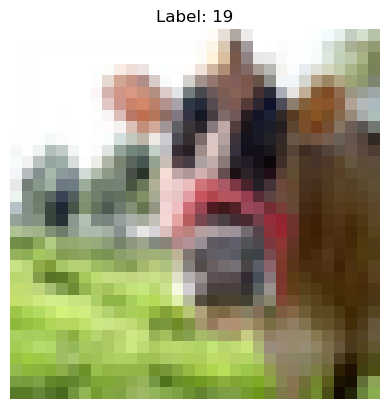

In [2]:
# 打印第一个图片看看图片和label
import matplotlib.pyplot as plt
plt.imshow(images[0].transpose(1, 2, 0))
plt.axis("off")
plt.title(f"Label: {labels[0]}")
plt.show()


准备训练和验证数据集
1. 数据归一化处理
2. 分割数据集

In [3]:
#首先看看二者大小是否一致

print("特征数据形状:", images.shape)
print("目标类 形状:", labels.shape)
images = images.astype(np.float32) / 255.0
# 切分
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    images,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)
print("训练集图片:", X_train.shape)
print("验证集图片:", X_val.shape)

print("训练集标签:", y_train.shape)
print("验证集标签:", y_val.shape)


特征数据形状: (50000, 3, 32, 32)
目标类 形状: (50000,)
训练集图片: (40000, 3, 32, 32)
验证集图片: (10000, 3, 32, 32)
训练集标签: (40000,)
验证集标签: (10000,)


使用pytorch

In [4]:
import torch
from torch.utils.data import Dataset, DataLoader
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


定义数据集合类和数据加载类

In [5]:
class CIFARDataset(Dataset):

    def __init__(self, images, labels,transform):
        self.images = torch.tensor(images, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)
        self.transform = transform
    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):

        image = self.images[index]
        label = self.labels[index]

        if self.transform:
            image = self.transform(image)

        return image, label

# =========================
# 数据增强
# =========================
from torchvision import transforms
#训练集转换+增强
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor()
])
#验证集只转换，不增强
val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor()
])


train_dataset = CIFARDataset(
    X_train,
    y_train,
    transform=train_transform
)

val_dataset = CIFARDataset(
    X_val,
    y_val,
    transform=val_transform
)
image, label = train_dataset[0]

print(image.shape)
print(label)
print("训练样本:", len(train_dataset))
print("验证样本:", len(val_dataset))

torch.Size([3, 32, 32])
tensor(34)
训练样本: 40000
验证样本: 10000


定义批处理和数据加载对象

In [6]:
batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

定义CNN网络

In [7]:
import torch.nn as nn
import torch.nn.functional as F

class CNN(nn.Module):

    def __init__(self):
        super().__init__()

        # First convolution layer
        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=32,
            kernel_size=3
        )

        # Second convolution layer
        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3
        )

        # Pooling layer
        self.pool = nn.MaxPool2d(2,2)

        # Fully connected layer
        self.fc1 = nn.Linear(
            64*6*6,
            256
        )

        # Output layer
        self.fc2 = nn.Linear(
            256,
            100
        )


    def forward(self, x):

        x = self.pool(F.relu(self.conv1(x)))

        x = self.pool(F.relu(self.conv2(x)))

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))

        x = self.fc2(x)

        return x

实例化cnn

In [8]:
model = CNN()
#设置使用cuda

model = model.to(device)
print(model)

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=2304, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=100, bias=True)
)


In [9]:
# 拿到第一批batch的图片和标签数据
images, labels = next(iter(train_loader))
images = images.to(device)
labels = labels.to(device)
print(images.shape)
print(labels.shape)


torch.Size([64, 3, 32, 32])
torch.Size([64])


In [10]:
images, labels = next(iter(train_loader))
images = images.to(device)
labels = labels.to(device)
output = model(images)

print("Input shape:", images.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([64, 3, 32, 32])
Output shape: torch.Size([64, 100])


定义损失函数和优化器

In [11]:
#使用交叉熵损失函数
criterion = nn.CrossEntropyLoss()
# 怎么根据错误修改模型参数
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)


In [12]:
# 查看下验证数据集
print("train labels:", torch.unique(train_dataset.labels))
print("val labels:", torch.unique(val_dataset.labels))


train labels: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
        36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53,
        54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71,
        72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89,
        90, 91, 92, 93, 94, 95, 96, 97, 98, 99])
val labels: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
        36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53,
        54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71,
        72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89,
        90, 91, 92, 93, 94, 95, 96, 97, 98, 99])


In [ ]:
#定义最佳准确率初始值
best_accuracy = 0.0

train_losses = []
train_accuracies = []
val_accuracies = []

# 加载模型
model = CNN().to(device)

# 加载之前保存的最佳模型参数
model.load_state_dict(
    torch.load("best_model.pth", map_location=device)
)

# 确保模型在 GPU
model = model.to(device)

print("模型加载完成")


# 整个训练集看10遍
num_epochs = 100
for epoch in range(num_epochs):

    # 设定模型为训练模式
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        # 转换成GPU tensor
        images = images.to(device)
        labels = labels.to(device)

        # 前向传播
        outputs = model(images)

        # 计算损失
        loss = criterion(outputs, labels)

        # 清除前向传播
        optimizer.zero_grad()

        # 后向传播：计算梯度
        loss.backward()

        # 更新参数
        optimizer.step()

        # 累计这一轮batch的所有损失值
        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        # 累加这个批次的数量
        total += labels.size(0)
        # 累加这个批次的计算正确的数量
        correct += (predicted == labels).sum().item()
    # 第n遍全数据集跑一遍的训练损失
    train_loss = running_loss / len(train_loader)
    # 第n遍全数据集跑一遍的训练精确度
    train_accuracy = 100 * correct / total

     # =========================
    # 2. 验证模式
    # =========================
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            # 转换成 GPU Tensor
            images = images.to(device)
            labels = labels.to(device)

            # 前向传播
            outputs = model(images)

            # 获取预测类别
            _, predicted = torch.max(outputs, 1)

            # 累加数量
            total += labels.size(0)

            # 累加正确数量
            correct += (predicted == labels).sum().item()

    # 计算验证集准确率
    validation_accuracy = 100 * correct / total

    # =========================
    # 3. 保存最佳模型
    # =========================
    if validation_accuracy > best_accuracy:

        best_accuracy = validation_accuracy

        torch.save(
            model.state_dict(),
            "best_model.pth"
        )

        print(">>> 保存新的最佳模型！")


    # =========================
    # 4. 打印结果
    # =========================
    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Accuracy: {train_accuracy:.2f}% "
        f"Val Accuracy: {validation_accuracy:.2f}%"
    )

    # 将每次epoch的数据加到列表中
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(validation_accuracy)
print(f"最佳验证集准确率为: {best_accuracy:.2f}%")

>>> 保存新的最佳模型！
Epoch [1/100] Train Loss: 2.0343 Train Accuracy: 45.72% Val Accuracy: 43.12%
>>> 保存新的最佳模型！
Epoch [2/100] Train Loss: 2.0068 Train Accuracy: 45.99% Val Accuracy: 43.26%
>>> 保存新的最佳模型！
Epoch [3/100] Train Loss: 2.0141 Train Accuracy: 46.18% Val Accuracy: 44.11%
Epoch [4/100] Train Loss: 2.0138 Train Accuracy: 45.86% Val Accuracy: 42.41%
Epoch [5/100] Train Loss: 2.0044 Train Accuracy: 46.14% Val Accuracy: 43.92%
>>> 保存新的最佳模型！
Epoch [6/100] Train Loss: 1.9984 Train Accuracy: 46.34% Val Accuracy: 44.67%
Epoch [7/100] Train Loss: 1.9883 Train Accuracy: 46.66% Val Accuracy: 43.76%
Epoch [8/100] Train Loss: 1.9922 Train Accuracy: 46.51% Val Accuracy: 44.45%
Epoch [9/100] Train Loss: 1.9811 Train Accuracy: 46.59% Val Accuracy: 44.01%
Epoch [10/100] Train Loss: 1.9813 Train Accuracy: 46.63% Val Accuracy: 44.48%
Epoch [11/100] Train Loss: 1.9800 Train Accuracy: 46.69% Val Accuracy: 44.37%


查看训练曲线

In [ ]:
import matplotlib.pyplot as plt

plt.plot(train_accuracies, label="训练准确率")
plt.plot(val_accuracies, label="验证准确率")

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.show()